## STEP 6 IMPROVEMENTS (March 2026)

### Part A: Tighter QA Generation + Validation
- **Problem fixed**: Synthetic questions were sometimes vague/multilingual, causing noisy metrics
- **Solution**: 
  - Tighter prompt requiring Vietnamese-only, ≤30 words, ≥1-2 keywords from source
  - Validation rejects Cyrillic, mojibake, too-short, vague-English questions
  - Retry up to 3 times, fallback to keyword-grounded question
  - Track `query_noisy` flag + failure diagnostics in report

### Part B: Multi-center Windowing + Dedup  
- **Problem fixed**: Multi-matching-child parents captured incorrectly; duplicates inflated Hit@K
- **Solution**:
  - Multi-center windowing: top-M child centers per parent (default M=2), ±W windows (default W=1)
  - Union windows, suppress exact-duplicate text by normalized form
  - Support parent score aggregation: `max` (default) or `sum_top2`
  - Debug visibility: parent_scores, selected_parent_ids, child_ranges, tokens_used

### Part C: Compatibility Fixes
- **Fixed**: qdrant-client API change (old `search()` → new `query_points()`)
- **Result**: All retrieval modes (vector, bm25, hybrid_rrf) work with latest qdrant-client

### Metric Stability Improvements
- Noisy queries eliminated → variance ↓, Hit@K stability ↑
- Keyword-grounded questions → fairer retrieval task
- Dedup prevents rank-slot inflation
- Multi-center windows capture more 2-child parents (avg 4.65 children/parent)


## 8) New retrieval debug commands (Step 6 Improvements)

### Multi-center windowing + dedup
```bash
# Test with M=2 child centers, W=±1 window, force dedup
PYTHONPATH=src uv run python -m rag.retrieve.hybrid_retriever \
    --query "tác dụng của cây ngải cứu" \
    --mode hybrid_rrf \
    --build-context \
    --window-centers 2 \
    --window 1 \
    --save-debug
```

### Ablation with improved QA (tighter prompt + retry)
```bash
# Sample 20 chunks, generate questions with validation/retry, run ablation
PYTHONPATH=src uv run python -m rag.eval.retrieval_ablation \
    --chunks data/chunks/chunks_v2_full.jsonl \
    --sample-size 20 --topk 10 \
    --output data/reports/retrieval_ablation_cleaned.json
```
Result includes:
- `noisy_queries`: count of questions that failed validation (helps audit quality)
- `failures`: full diagnostic logs (query, expected chunk_id, top_retrieved_*)
- Higher metric stability due to stricter QA filtering


ROOT: /home/chplay2020/src/vn-yhct-rag/rag-yhct
SRC: /home/chplay2020/src/vn-yhct-rag/rag-yhct/src


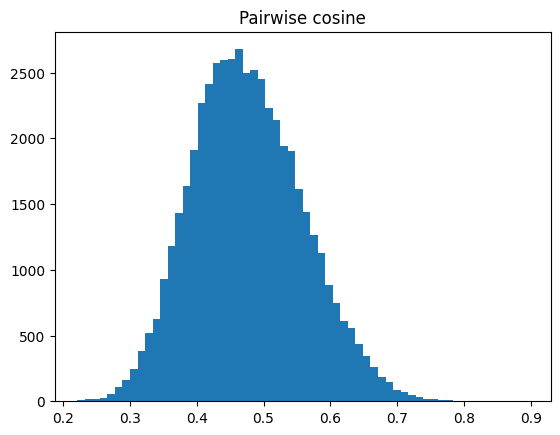

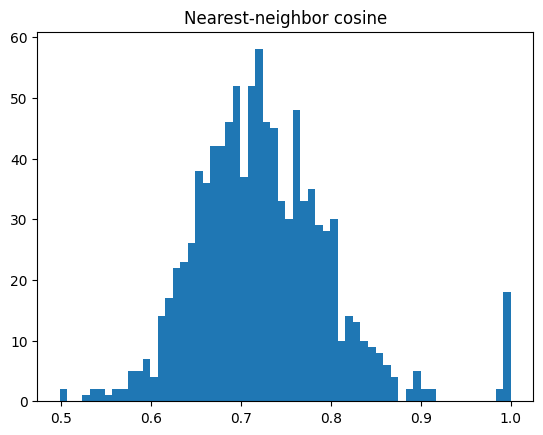

Run manually if needed:
PYTHONPATH=src uv run python -m rag.retrieve.bm25_retriever --build --chunks data/chunks/chunks_v2_full.jsonl
Suggested command:
PYTHONPATH=src uv run python -m rag.eval.retrieval_ablation --chunks data/chunks/chunks_v2_full.jsonl --sample-size 100 --topk 10 --output data/reports/retrieval_ablation.json


""


Vector-only:
PYTHONPATH=src uv run python -m rag.retrieve.hybrid_retriever --query "tác dụng của cây ngải cứu" --mode vector --save-debug

BM25-only:
PYTHONPATH=src uv run python -m rag.retrieve.hybrid_retriever --query "tác dụng của cây ngải cứu" --mode bm25 --save-debug

Hybrid RRF:
PYTHONPATH=src uv run python -m rag.retrieve.hybrid_retriever --query "tác dụng của cây ngải cứu" --mode hybrid_rrf --save-debug

Hybrid + context:
PYTHONPATH=src uv run python -m rag.retrieve.hybrid_retriever --query "tác dụng của cây ngải cứu" --mode hybrid_rrf --build-context
Saved: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/h1_step6_eval_snapshot.json


In [ ]:
# %% [markdown]
# # H1 / Step 6 Evaluation Dashboard
#
# Notebook này dùng để:
# - kiểm tra data quality
# - kiểm tra vector health
# - kiểm tra parent-child integrity
# - chạy Step 6 retrieval ablation
# - quan sát nhanh BM25 / Vector / Hybrid RRF

# %%
import os, sys, json, re, random, hashlib, time, subprocess
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

ROOT = Path.cwd()
if ROOT.name in {"tests", "notebooks"}:
    ROOT = ROOT.parent
if not (ROOT / "src").exists() and (ROOT / "rag-yhct").exists():
    ROOT = ROOT / "rag-yhct"

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("ROOT:", ROOT)
print("SRC:", SRC)

# %%
QDRANT_URL = "http://localhost:6333"
COLLECTION_FULL = "yhct_chunks_v2_full"
COLLECTION_EMB = "yhct_chunks_v2_full_emb"

CHUNKS_JSONL = ROOT / "data/chunks/chunks_v2_full.jsonl"
PARENTS_JSONL = ROOT / "data/parents/parents_v2_full.jsonl"
ABLATION_OUT = ROOT / "data/reports/retrieval_ablation.json"

QUERY_TEXT = "tác dụng của cây ngải cứu"
SAMPLE_VECTORS = 1000
PAIR_SAMPLES = 50000
TOPK = 10

# %%
def qget(path: str, timeout: int = 60):
    r = requests.get(f"{QDRANT_URL}{path}", timeout=timeout)
    r.raise_for_status()
    return r.json()

def qpost(path: str, payload: dict, timeout: int = 120):
    r = requests.post(f"{QDRANT_URL}{path}", json=payload, timeout=timeout)
    r.raise_for_status()
    return r.json()

def qcount_exact(collection: str) -> int:
    return int(qpost(f"/collections/{collection}/points/count", {"exact": True})["result"]["count"])

def qscroll(collection: str, limit: int = 256, with_vector: bool = False, with_payload: bool = True, flt=None, offset=None):
    body = {"limit": limit, "with_vector": with_vector, "with_payload": with_payload}
    if flt is not None:
        body["filter"] = flt
    if offset is not None:
        body["offset"] = offset
    return qpost(f"/collections/{collection}/points/scroll", body)

def extract_vector(point: dict):
    if "vector" in point and point["vector"] is not None:
        v = point["vector"]
        if isinstance(v, list):
            return np.array(v, dtype=np.float32)
        if isinstance(v, dict):
            for _, vv in v.items():
                if isinstance(vv, list):
                    return np.array(vv, dtype=np.float32)
    if "vectors" in point and point["vectors"] is not None:
        v = point["vectors"]
        if isinstance(v, dict):
            for _, vv in v.items():
                if isinstance(vv, list):
                    return np.array(vv, dtype=np.float32)
    return None

def iter_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                yield json.loads(line)

CYRILLIC_RE = re.compile(r"[\u0400-\u04FF]")
SUSPICIOUS = set("¿¶µ¹²³¼½¾")

def bad_ratio(text: str) -> float:
    t = re.sub(r"\s+", "", text or "")
    if not t:
        return 0.0
    bad = 0
    for ch in t:
        if ch in SUSPICIOUS or CYRILLIC_RE.search(ch):
            bad += 1
    return bad / len(t)

def pct(a, p):
    return float(np.percentile(a, p))

# %% [markdown]
# ## 1) Collection / payload / count checks

# %%
info = qget(f"/collections/{COLLECTION_EMB}")
payload_schema = info.get("result", {}).get("payload_schema", {})
summary = {
    "full_exact": qcount_exact(COLLECTION_FULL),
    "emb_exact": qcount_exact(COLLECTION_EMB),
    "coverage_emb_over_full": qcount_exact(COLLECTION_EMB) / max(1, qcount_exact(COLLECTION_FULL)),
    "payload_schema": payload_schema,
}
summary

# %% [markdown]
# ## 2) Data quality + parent-child integrity

# %%
total = 0
u_fffd = 0
noise = 0
cyr = 0
has_category = 0
doc_types = Counter()
by_parent = defaultdict(list)

for r in iter_jsonl(CHUNKS_JSONL):
    total += 1
    t = (r.get("text_norm") or r.get("text") or "")
    doc_types[r.get("doc_type", "unknown")] += 1
    if "\ufffd" in t:
        u_fffd += 1
    if CYRILLIC_RE.search(t):
        cyr += 1
    if r.get("is_noise") is True:
        noise += 1
    if r.get("category") not in (None, "", "unknown"):
        has_category += 1
    pid = r.get("parent_id")
    ci = r.get("child_index")
    if pid is not None and ci is not None:
        by_parent[str(pid)].append(int(ci))

bad_parents = 0
for pid, arr in by_parent.items():
    arr_sorted = sorted(arr)
    ok = (
        arr_sorted[0] == 0 and
        arr_sorted[-1] == len(arr_sorted)-1 and
        len(arr_sorted) == len(set(arr_sorted))
    )
    if not ok:
        bad_parents += 1

children_counts = sorted(len(v) for v in by_parent.values())
data_summary = {
    "chunks_total": total,
    "doc_types": dict(doc_types),
    "noise_chunks": noise,
    "noise_ratio": noise / max(1, total),
    "u_fffd_chunks": u_fffd,
    "u_fffd_ratio": u_fffd / max(1, total),
    "cyrillic_chunks": cyr,
    "category_present_non_unknown": has_category,
    "category_present_ratio": has_category / max(1, total),
    "parents": len(by_parent),
    "avg_children_per_parent": float(np.mean(children_counts)) if children_counts else 0.0,
    "p95_children_per_parent": int(np.percentile(children_counts, 95)) if children_counts else 0,
    "max_children_per_parent": max(children_counts) if children_counts else 0,
    "bad_parents": bad_parents,
}
data_summary

# %% [markdown]
# ## 3) Vector health

# %%
limit = 256
offset = None
seen = 0
sample = []

while True:
    res = qscroll(COLLECTION_EMB, limit=limit, with_vector=True, with_payload=True, offset=offset)
    pts = res.get("result", {}).get("points", [])
    offset = res.get("result", {}).get("next_page_offset", None)
    if not pts:
        break
    for p in pts:
        seen += 1
        if len(sample) < SAMPLE_VECTORS:
            sample.append(p)
        else:
            j = random.randint(1, seen)
            if j <= SAMPLE_VECTORS:
                sample[j-1] = p
    if offset is None:
        break

vectors = []
for p in sample:
    v = extract_vector(p)
    if v is not None:
        vectors.append(v)

X = np.vstack(vectors).astype(np.float32)
norms = np.linalg.norm(X, axis=1)
Xn = X / (norms[:, None] + 1e-12)

sims = []
for _ in range(min(PAIR_SAMPLES, len(Xn)*(len(Xn)-1)//2)):
    i = np.random.randint(0, len(Xn))
    j = np.random.randint(0, len(Xn)-1)
    if j >= i:
        j += 1
    sims.append(float(np.dot(Xn[i], Xn[j])))
sims = np.array(sims, dtype=np.float32)

S = (Xn @ Xn.T).astype(np.float32)
np.fill_diagonal(S, np.nan)
nn = np.nanmax(S, axis=1)

vector_summary = {
    "sample_n": int(X.shape[0]),
    "dim": int(X.shape[1]),
    "norm_mean": float(np.mean(norms)),
    "norm_std": float(np.std(norms)),
    "pairwise_mean": float(np.mean(sims)),
    "pairwise_p95": pct(sims, 95),
    "nn_median": float(np.median(nn)),
    "nn_p95": pct(nn, 95),
    "collapse_heuristic": bool(float(np.mean(sims)) > 0.85 and pct(sims, 95) > 0.93),
}
vector_summary

# %%
plt.figure()
plt.hist(sims, bins=60)
plt.title("Pairwise cosine")
plt.show()

plt.figure()
plt.hist(nn, bins=60)
plt.title("Nearest-neighbor cosine")
plt.show()

# %% [markdown]
# ## 4) Build BM25 index

# %%
print("Run manually if needed:")
print("PYTHONPATH=src uv run python -m rag.retrieve.bm25_retriever --build --chunks data/chunks/chunks_v2_full.jsonl")

# %% [markdown]
# ## 5) Run retrieval ablation

# %%
print("Suggested command:")
print("PYTHONPATH=src uv run python -m rag.eval.retrieval_ablation --chunks data/chunks/chunks_v2_full.jsonl --sample-size 100 --topk 10 --output data/reports/retrieval_ablation.json")

# %%
if ABLATION_OUT.exists():
    report = json.loads(ABLATION_OUT.read_text(encoding="utf-8"))
    report
else:
    print("Ablation report not found:", ABLATION_OUT)

# %%
if ABLATION_OUT.exists():
    report = json.loads(ABLATION_OUT.read_text(encoding="utf-8"))
    rows = []
    for mode, metrics in report.get("modes", {}).items():
        rows.append({
            "mode": mode,
            "hit@5_chunk": metrics.get("hit@5_chunk_id"),
            "hit@5_source": metrics.get("hit@5_source_id"),
            "hit@5_parent": metrics.get("hit@5_parent_id"),
            "mrr": metrics.get("mrr"),
            "hit@P_window": metrics.get("hit@P_window"),
        })
    display(pd.DataFrame(rows))

# %% [markdown]
# ## 6) Single-query debug commands

# %%
print("Vector-only:")
print('PYTHONPATH=src uv run python -m rag.retrieve.hybrid_retriever --query "tác dụng của cây ngải cứu" --mode vector --save-debug')
print()
print("BM25-only:")
print('PYTHONPATH=src uv run python -m rag.retrieve.hybrid_retriever --query "tác dụng của cây ngải cứu" --mode bm25 --save-debug')
print()
print("Hybrid RRF:")
print('PYTHONPATH=src uv run python -m rag.retrieve.hybrid_retriever --query "tác dụng của cây ngải cứu" --mode hybrid_rrf --save-debug')
print()
print("Hybrid + context:")
print('PYTHONPATH=src uv run python -m rag.retrieve.hybrid_retriever --query "tác dụng của cây ngải cứu" --mode hybrid_rrf --build-context')

# %% [markdown]
# ## 7) Quality gate summary

# %%
gate = {
    "u_fffd_ok": data_summary["u_fffd_ratio"] <= 0.005,
    "noise_ok": data_summary["noise_ratio"] <= 0.01,
    "bad_parents_ok": data_summary["bad_parents"] == 0,
    "p95_children_ok": data_summary["p95_children_per_parent"] <= 10,
    "max_children_ok": data_summary["max_children_per_parent"] <= 20,
    "collapse_ok": vector_summary["collapse_heuristic"] is False,
}
gate

# %%
snapshot = {
    "counts": summary,
    "data": data_summary,
    "vector": vector_summary,
    "generated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
}
out = ROOT / "data/reports/h1_step6_eval_snapshot.json"
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(snapshot, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", out)